In [45]:
EXPERIMENTAL_ID="ltr_rerank"
START_DATE="2026-01-07"

In [46]:
from odps_client import get_odps_sql_result_as_df
from datetime import datetime, timedelta


In [47]:
from sls_client import get_sls_data_by_query
from datetime import datetime, timedelta
import pandas as pd

# 设置pandas显示选项以展示更多内容
pd.set_option("display.max_rows", 100)  # 显示最多100行
pd.set_option("display.max_columns", None)  # 显示所有列
pd.set_option("display.width", 1000)  # 设置显示宽度
pd.set_option("display.max_colwidth", 100)  # 设置列最大宽度

import sqlite3


def get_user_variant_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    """
    从SLS(Simple Log Service)获取指定日期的用户变体数据。

    Args:
        day (datetime): 要获取数据的日期。
        check_if_local_exist (bool): 是否检查本地数据库中是否已存在数据，默认为True。

    Returns:
        pd.DataFrame: 包含用户变体数据的DataFrame。
    """
    # 构建数据库文件名和表名
    db_file_name = f"./data/category_ltr_ab_user_variant.db"
    table_name = f"recommend_ab_user_variant_{day.strftime('%Y%m%d')}"
    # 连接到SQLite数据库
    conn = sqlite3.connect(db_file_name)

    # 如果设置为检查本地数据
    if check_if_local_exist:
        try:
            # 尝试从数据库中读取数据
            query = f"SELECT * FROM {table_name}"
            df = pd.read_sql_query(query, conn)
            # 关闭数据库连接
            conn.close()
            # 返回读取的数据
            return df
        except pd.io.sql.DatabaseError:
            # 如果表不存在，则忽略错误
            pass

    # 构建SLS查询语句
    query = f"""
type:a and ap:/product
| SELECT 
    regexp_replace(ap, '\d+','{{digit}}') as api,
    case when pageName in ('/goods','/goods/category') then '/goods' else 'null' end as page_name,
    regexp_extract(experiment_item, '"experimentId":"([^"]+)"', 1) as experiment_id,
    type,
    uid,
    date_format(__time__, '%Y%m%d') as ds,
    count(1) as search_times,
    array_join(array_sort(array_agg(distinct regexp_extract(experiment_item, '"variantId":"([^"]+)"', 1))),',') as variant_list
FROM log, 
UNNEST(regexp_extract_all(json_extract_scalar(ai, '$.qh.xm-ab-exp'), '\{{[^}}]+\}}')) as t(experiment_item)
WHERE experiment_item LIKE '%"experimentId":"{EXPERIMENTAL_ID}"%'
GROUP BY 1,2,3,4,5,6
HAVING page_name = '/goods'
LIMIT 1000000
"""
    # 设置查询的起始时间和结束时间
    print(query)
    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    # 从SLS获取数据
    _df = get_sls_data_by_query(
        query=query,
        project="xianmu-front-end-log",  # 指定SLS项目
        logstore="xm-mall",  # 指定SLS日志库
        from_time=from_time,  # 指定查询起始时间
        to_time=to_time,  # 指定查询结束时间
    )

    # 将search_times列中的缺失值填充为1，并转换为整数类型
    _df["search_times"] = _df["search_times"].fillna(1).astype(int)
    # 将variant_list列中的缺失值填充为"none"
    _df["variant_list"] = _df["variant_list"].fillna("none")

    # 如果DataFrame不为空
    if not _df.empty:
        # 删除不需要的列
        _df.drop(columns=["__source__", "__time__"], inplace=True)
        # 将数据写入SQLite数据库，如果表已存在则替换
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    # 关闭数据库连接
    conn.close()
    # 返回数据
    return _df


# 创建一个空的DataFrame来存储所有日期的用户变体数据
all_user_variant_df = pd.DataFrame()
# 设置起始日期和结束日期
start_date = datetime.strptime(START_DATE, "%Y-%m-%d")
end_date = datetime.now()
# 从起始日期开始循环，直到结束日期
current_date = start_date
while current_date <= end_date:
    # 检查是否是今天
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    # 如果是今天,则跳过，因为今天的数据可能不完整
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    # 获取当前日期的用户变体数据
    df = get_user_variant_of_date_from_sls(current_date, check_if_local_exist=True)
    # 将当前日期的数据添加到总的DataFrame中
    all_user_variant_df = pd.concat([all_user_variant_df, df], ignore_index=True)
    # 日期增加一天
    current_date += timedelta(days=1)

# 显示前10行数据
all_user_variant_df.head(10)


type:a and ap:/product
| SELECT 
    regexp_replace(ap, '\d+','{digit}') as api,
    case when pageName in ('/goods','/goods/category') then '/goods' else 'null' end as page_name,
    regexp_extract(experiment_item, '"experimentId":"([^"]+)"', 1) as experiment_id,
    type,
    uid,
    date_format(__time__, '%Y%m%d') as ds,
    count(1) as search_times,
    array_join(array_sort(array_agg(distinct regexp_extract(experiment_item, '"variantId":"([^"]+)"', 1))),',') as variant_list
FROM log, 
UNNEST(regexp_extract_all(json_extract_scalar(ai, '$.qh.xm-ab-exp'), '\{[^}]+\}')) as t(experiment_item)
WHERE experiment_item LIKE '%"experimentId":"ltr_rerank"%'
GROUP BY 1,2,3,4,5,6
HAVING page_name = '/goods'
LIMIT 1000000

即将获取数据: =====> 2026-01-07 00:00:00 2026-01-07 23:59:59.999999 xm-mall: 
type:a and ap:/product
| SELECT 
    regexp_replace(ap, '\d+','{digit}') as api,
    case when page
>=====数条数:7184

type:a and ap:/product
| SELECT 
    regexp_replace(ap, '\d+','{digit}') as api,
    ca

,api,page_name,experiment_id,type,uid,ds,search_times,variant_list
0,/product,/goods,ltr_rerank,a,469239,20260107,33,V3
1,/product,/goods,ltr_rerank,a,295052,20260107,7,V4
2,/product,/goods,ltr_rerank,a,544024,20260107,57,V3
3,/product,/goods,ltr_rerank,a,195672,20260107,2,V2
4,/product,/goods,ltr_rerank,a,104248,20260107,1,V4
5,/product,/goods,ltr_rerank,a,298535,20260107,11,V1
6,/product,/goods,ltr_rerank,a,309018,20260107,55,V1
7,/product,/goods,ltr_rerank,a,567093,20260107,69,V2
8,/product,/goods,ltr_rerank,a,600992,20260107,11,V3
9,/product,/goods,ltr_rerank,a,343244,20260107,1,V2


In [48]:
import pandasql
stats=pandasql.sqldf("""select ds,variant_list,count(distinct uid) unique_user 
                     from all_user_variant_df group by ds,variant_list order by ds desc,variant_list""")

display(stats)

,ds,variant_list,unique_user
0,20260111,V1,1447
1,20260111,V2,1422
2,20260111,V3,1514
3,20260111,V4,1458
4,20260110,V1,1665
5,20260110,V2,1655
6,20260110,V3,1600
7,20260110,V4,1652
8,20260109,V1,1848
9,20260109,V2,1823


In [49]:
# idx:4,name:徐州奶油草莓 净重3-3.2斤/一级/单果10g+/板装,pid:goods,sku:5442468008,salePrice:69.5,pdid:702,stock:10000,ext:cross;idx:5,name:徐州奶油草莓 280G*1盒/一级/4*6/ ,pid:goods,sku:5442468073,salePrice:16.5,pdid:702,stock:10000,ext:cross;idx:6,name:徐州奶油草莓 净重2.8-3斤/一级/单果10g+/ 10盒,pid:goods,sku:5442468518,salePrice:74.5,pdid:702,stock:10000,ext:cross

view_query = """
type:cl or type:view | select ds,
    '/goods' as "页面名称",uid,sku_viewed_or_clicked,
    count(distinct case when type='view' and position_id='goods' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "SKU曝光次数",
    count(distinct case when type='cl' and position_id in ('goods','唤起购买') then (uid,sku_viewed_or_clicked,__time__,idx) end) as "SKU点击次数",
    round(1.00*count(distinct case when type='cl' and position_id in ('goods','唤起购买') then (uid,sku_viewed_or_clicked,__time__,idx) end)/count(distinct case when type='view' and position_id='goods' then (uid,sku_viewed_or_clicked,__time__,idx) end),4) as "SKU点击率",
    count(distinct case when type='cl' and position_id in ('goods','唤起购买') and idx <= 3 then (uid,sku_viewed_or_clicked,__time__,idx) end) as "前4位SKU点击次数",
    count(distinct case when type='cl' and position_id='唤起购买' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "唤起加购弹窗点击次数",
    count(distinct case when type='cl' and position_id='加购弹窗' and position_name='加入购物车' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "加入购物车次数",
    count(distinct case when type='cl' and position_id='加购弹窗' and position_name='立即购买' then (uid,sku_viewed_or_clicked,__time__,idx) end) as "立即购买次数",
    round(avg(case when type='cl' then idx end),2) as "平均点击位置",
    max(case when type='cl' then idx end) as "最大点击位置",
    min(case when type='cl' then idx end) as "最小点击位置",
    round(avg(case when type='view' and position_id='goods' then idx end),2) as "平均曝光位置",
    max(case when type='view' and position_id='goods' then idx end) as "最大曝光位置",
    min(case when type='view' and position_id='goods' then idx end) as "最小曝光位置",
    count(0) as "总事件数" 
from (
    select pageName,
        type,
        case when COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) in ('goods','唤起购买') and type='cl' 
            then COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) 
            else COALESCE(regexp_extract(bid, 'name:([^,]+)', 1),name) 
        end as position_name,
        COALESCE(regexp_extract(bid, 'pid:([^,]+)', 1),pid) as position_id,
        uid,__time__,
        cast(COALESCE(regexp_extract(bid, 'idx:([0-9]+)', 1),idx) as bigint) as idx,
        COALESCE(regexp_extract(bid, 'sku:([0-9a-zA-Z]{1,20})', 1),sku) as sku_viewed_or_clicked,
        date_format(__time__,'%Y%m%d') ds
    from log 
    where pageName in ('/goods','/goods/category')
        and COALESCE(regexp_extract(bid, 'sku:([0-9a-zA-Z]{1,20})', 1),sku) is not null 
    limit 100000000
)
group by 1,2,3,4
having length(uid)>0
order by 5 desc
"""


def get_user_sku_view_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    db_file_name = f"./data/category_ltr_ab_user_sku_view.db"
    table_name = f"user_sku_view_{day.strftime('%Y%m%d')}"
    conn = sqlite3.connect(db_file_name)
    cursor = conn.cursor()

    if check_if_local_exist:
        try:
            query = f"SELECT * FROM {table_name}"
            df = pd.read_sql_query(query, conn)
            conn.close()
            return df
        except pd.io.sql.DatabaseError:
            pass

    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    _df = get_sls_data_by_query(
        query=view_query,
        project="xianmu-front-end-log",
        logstore="xm-mall",
        from_time=from_time,
        to_time=to_time,
    )

    if not _df.empty:
        _df.drop(columns=["__source__", "__time__"], inplace=True)
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    conn.close()
    return _df


all_user_sku_view_df = pd.DataFrame()
current_date = start_date
while current_date <= end_date:
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    df = get_user_sku_view_of_date_from_sls(current_date, check_if_local_exist=True)
    all_user_sku_view_df = pd.concat([all_user_sku_view_df, df], ignore_index=True)
    current_date += timedelta(days=1)

即将获取数据: =====> 2026-01-07 00:00:00 2026-01-07 23:59:59.999999 xm-mall: 
type:cl or type:view | select ds,
    '/goods' as "页面名称",uid,sku_viewed_or_clicked,
    count(disti
>=====数条数:218050
即将获取数据: =====> 2026-01-08 00:00:00 2026-01-08 23:59:59.999999 xm-mall: 
type:cl or type:view | select ds,
    '/goods' as "页面名称",uid,sku_viewed_or_clicked,
    count(disti
>=====数条数:220576
即将获取数据: =====> 2026-01-09 00:00:00 2026-01-09 23:59:59.999999 xm-mall: 
type:cl or type:view | select ds,
    '/goods' as "页面名称",uid,sku_viewed_or_clicked,
    count(disti
>=====数条数:209554
即将获取数据: =====> 2026-01-10 00:00:00 2026-01-10 23:59:59.999999 xm-mall: 
type:cl or type:view | select ds,
    '/goods' as "页面名称",uid,sku_viewed_or_clicked,
    count(disti
>=====数条数:170911
即将获取数据: =====> 2026-01-11 00:00:00 2026-01-11 23:59:59.999999 xm-mall: 
type:cl or type:view | select ds,
    '/goods' as "页面名称",uid,sku_viewed_or_clicked,
    count(disti
>=====数条数:157139
今天的数据还未完整，跳过:2026-01-12 00:00:00


In [50]:
all_user_sku_view_df.head(20)

,ds,页面名称,uid,sku_viewed_or_clicked,SKU曝光次数,SKU点击次数,SKU点击率,前4位SKU点击次数,唤起加购弹窗点击次数,加入购物车次数,立即购买次数,平均点击位置,最大点击位置,最小点击位置,平均曝光位置,最大曝光位置,最小曝光位置,总事件数
0,20260107,/goods,204415,28617,31,0,0.0,0,0,0,0,null,null,null,1.16,12,0,31
1,20260107,/goods,445546,28482,31,0,0.0,0,0,0,0,null,null,null,5.84,31,0,31
2,20260107,/goods,373992,36655,26,0,0.0,0,0,0,0,null,null,null,3.08,17,0,26
3,20260107,/goods,445546,36375,23,0,0.0,0,0,0,0,null,null,null,10.83,36,1,23
4,20260107,/goods,506991,832317132722,22,1,0.0455,1,0,0,0,0.0,0,0,0.0,0,0,23
5,20260107,/goods,204415,28336,21,1,0.0476,0,0,0,0,4.0,4,4,5.05,14,4,22
6,20260107,/goods,204415,533087318343,21,2,0.0952,2,0,0,0,3.0,3,3,3.19,6,3,23
7,20260107,/goods,373992,N001S01R005,21,6,0.2857,6,4,0,0,0.0,0,0,5.43,57,0,31
8,20260107,/goods,506991,605353800833,20,0,0.0,0,0,0,0,null,null,null,0.0,0,0,20
9,20260107,/goods,445546,28230,20,1,0.05,0,0,0,0,35.0,35,35,19.05,35,4,21


In [34]:
all_user_sku_view_df.groupby("ds").size().reset_index(name="count").sort_values(
    "ds", ascending=False
).head(10)

user_click_with_variant_statistics_df = all_user_sku_view_df.merge(
    all_user_variant_df[["uid", "ds", "variant_list"]],
    on=["uid", "ds"],
    how="left",
)

print("non variant count:", user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].isna()
].shape[0])

print("total count:", len(user_click_with_variant_statistics_df))

print("variant count:", len(user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]))

variant_ratio = len(user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]) / len(user_click_with_variant_statistics_df)
print("variant ratio:", f"{variant_ratio:.4%}")

user_click_with_variant_statistics_df.head(5)

print("drop non variant users...")
user_click_with_variant_statistics_df = user_click_with_variant_statistics_df[
    user_click_with_variant_statistics_df["variant_list"].notna()
]

non variant count: 46
total count: 990252
variant count: 990206
variant ratio: 99.9954%
drop non variant users...


In [54]:
print(user_click_with_variant_statistics_df.columns)

Index(['ds', '页面名称', 'uid', 'sku_viewed_or_clicked', 'SKU曝光次数', 'SKU点击次数', 'SKU点击率', '前4位SKU点击次数', '唤起加购弹窗点击次数', '加入购物车次数', '立即购买次数', '平均点击位置', '最大点击位置', '最小点击位置', '平均曝光位置', '最大曝光位置', '最小曝光位置', '总事件数', 'variant_list', 'create_time'], dtype='object')


In [55]:
user_click_with_variant_statistics_df.head(20)

user_sku_view_serial = (
    user_click_with_variant_statistics_df
    .groupby(["variant_list", "uid"])
    .agg({"SKU曝光次数": "sum"})
    .reset_index()  # This converts the index levels into columns
)

user_sku_view_serial.head(5)

,variant_list,uid,SKU曝光次数
0,V1,100027,37
1,V1,100041,24
2,V1,10014,7
3,V1,10019,109
4,V1,10022,89


In [63]:
# 1. Force the column to be numeric
# 'coerce' turns non-numeric junk into NaN so the code doesn't crash
user_click_with_variant_statistics_df['平均点击位置'] = pd.to_numeric(
    user_click_with_variant_statistics_df['平均点击位置'], 
    errors='coerce'
)

# 2. Now run your aggregation
user_avg_position_serial = (
    user_click_with_variant_statistics_df[user_click_with_variant_statistics_df['SKU点击次数'] > 0]
    .groupby(["variant_list", "uid"])
    .agg({"平均点击位置": "mean"}) 
    .reset_index()
)

user_avg_position_serial.head(5)

,variant_list,uid,平均点击位置
0,V1,100027,2.833333
1,V1,100041,0.400000
2,V1,10014,2.500000
3,V1,10019,15.800000
4,V1,10022,82.666667


In [ ]:
user_sku_click_serial = (
    user_click_with_variant_statistics_df
    .groupby(["variant_list", "uid"])
    .agg({"SKU点击次数": "sum"})
    .reset_index()  # This converts the index levels into columns
)

user_sku_click_serial.head(5)

In [57]:
# 1. Group and aggregate both Clicks and Impressions
user_sku_ctr_serial = (
    user_click_with_variant_statistics_df
    .groupby(["variant_list", "uid"])
    .agg({
        "SKU点击次数": "sum", # Clicks
        "SKU曝光次数": "sum"  # Impressions
    })
    .reset_index()
)

# 2. Calculate the CTR column
# CTR = Total Clicks / Total Impressions
user_sku_ctr_serial['CTR'] = user_sku_ctr_serial['SKU点击次数'] / user_sku_ctr_serial['SKU曝光次数']

# 3. Optional: Fill NaNs with 0 if there are cases with 0 impressions
user_sku_ctr_serial['CTR'] = user_sku_ctr_serial['CTR'].fillna(0)

user_sku_ctr_serial.head(5)

,variant_list,uid,SKU点击次数,SKU曝光次数,CTR
0,V1,100027,6,37,0.162162
1,V1,100041,6,24,0.250000
2,V1,10014,2,7,0.285714
3,V1,10019,6,109,0.055046
4,V1,10022,3,89,0.033708


## 以下是ODPS分析

In [ ]:
from odps_client import get_odps_sql_result_as_df, write_pandas_df_into_odps
from datetime import datetime

table_name = "summerfarm_ds.temp_category_ltr_ab_all_user_view_data_df"
partition_spec = f"ds={datetime.now().strftime('%Y%m%d')}"
write_pandas_df_into_odps(
    df=user_click_with_variant_statistics_df,
    table_name=table_name,
    partition_spec=partition_spec,
    overwrite=True,
    lifecycle=30,
)
print(f"数据已成功写入ODPS表: {table_name}，分区: {partition_spec}")
print(f"数据行数: {len(user_click_with_variant_statistics_df)}")


In [40]:
from odps_client import get_odps_sql_result_as_df
from datetime import datetime,timedelta

DAYS_TO_BE_NEW_SKU=3650
order_date_to_be_new_sku=(datetime.now()-timedelta(days=DAYS_TO_BE_NEW_SKU)).strftime("%Y%m%d")

sku_view_sql=f"""
SELECT  expe.variant_list
        ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                ELSE '新SKU'
        END AS 是否新SKU
        ,COUNT(DISTINCT expe.uid) 用户数
        ,SUM(sku点击总次数) sku点击总次数
        ,SUM(sku曝光总次数) sku曝光总次数
        ,SUM(加入购物车立即购买总次数) 加入购物车立即购买总次数
FROM    (
            SELECT  uid
                    ,variant_list
                    ,sku_viewed_or_clicked
                    ,SUM(COALESCE(sku点击次数,0)) sku点击总次数
                    ,SUM(sku曝光次数) sku曝光总次数
                    ,SUM(COALESCE(加入购物车次数,0)+COALESCE(立即购买次数,0)) 加入购物车立即购买总次数
            FROM    {table_name}
            WHERE   ds = MAX_PT('{table_name}')
            GROUP BY uid
                     ,variant_list
                     ,sku_viewed_or_clicked
        ) expe
LEFT JOIN   (
                SELECT  cust_id
                        ,sku_id
                        ,COUNT(*) viewed_cnt
                FROM    summerfarm_tech.dwd_trd_order_df 
                WHERE   ds = MAX_PT('summerfarm_tech.dwd_trd_order_df')
                AND     order_date >= '{order_date_to_be_new_sku}'
                GROUP BY cust_id
                         ,sku_id
            ) old
ON      expe.uid = old.cust_id
AND     expe.sku_viewed_or_clicked = old.sku_id
GROUP BY expe.variant_list
         ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                 ELSE '新SKU'
         END 
order by expe.variant_list
         ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                 ELSE '新SKU'
         END;
"""

result_df=get_odps_sql_result_as_df(sku_view_sql)
result_df

2026-01-12 13:44:01 - INFO - Tunnel session created: <InstanceDownloadSession id=20260112134401641d3b1a13a553c5 project_name=summerfarm_ds instance_id=20260112054328764gua5l5y519g>
2026-01-12 13:44:02 - INFO - sql:

SELECT  expe.variant_list
        ,CASE   WHEN old.viewed_cnt > 0 THEN '之前购买过的SKU'
                ELSE '新SKU'
        END AS 是否新SKU
        ,COUNT(DISTINCT expe.uid) 用户数
        ,SUM(sku点击总次数) sku点击总次数
        ,SUM(sku曝光总次数) sku曝光总次数
        ,SUM(加入购物车立即购买总次数) 加入购物车立即购买总次数
FROM    (
            SELECT  uid
                    ,variant_list
                    ,sku_viewed_or_clicked
                    ,SUM(COALESCE(sku点击次数,0)) sku点击总次数
                    ,SUM(sku曝光次数) sku曝光总次数
                    ,SUM(COALESCE(加入购物车次数,0)+COALESCE(立即购买次数,0)) 加入购物车立即购买总次数
            FROM    summerfarm_ds.temp_category_ltr_ab_all_user_view_data_df
            WHERE   ds = MAX_PT('summerfarm_ds.temp_category_ltr_ab_all_user_view_data_df')
            GROUP BY uid
                     ,varian

,variant_list,是否新sku,用户数,sku点击总次数,sku曝光总次数,加入购物车立即购买总次数
0,V1,之前购买过的SKU,3843,10467,43779,943
1,V1,新SKU,5019,7374,247194,117
2,V2,之前购买过的SKU,3810,9666,40852,825
3,V2,新SKU,5071,7389,248484,95
4,V3,之前购买过的SKU,3895,10268,44622,880
5,V3,新SKU,5187,7063,261427,77
6,V4,之前购买过的SKU,3905,10715,45541,874
7,V4,新SKU,5088,7326,258639,80


In [41]:
result_df['SKU点击率']=result_df['sku点击总次数']/result_df['sku曝光总次数']
variant_group=result_df.groupby('variant_list').agg({'sku点击总次数':'sum','sku曝光总次数':'sum','加入购物车立即购买总次数':'sum'}).reset_index()
variant_group['分组SKU点击率']=variant_group['sku点击总次数']/variant_group['sku曝光总次数']
variant_group['分组加入购物车立即购买率']=variant_group['加入购物车立即购买总次数']/variant_group['sku曝光总次数']

variant_group.columns=['variant_list', '分组sku点击总次数','分组sku曝光总次数','分组加入购物车立即购买总次数','分组SKU点击率','分组加入购物车立即购买率']

v2_ctr=variant_group[variant_group['variant_list']=='V2']['分组SKU点击率'].values[0]
v2_jg=variant_group[variant_group['variant_list']=='V2']['分组加入购物车立即购买率'].values[0]
result_final_df=result_df.merge(variant_group,on='variant_list',how='left')
result_final_df['V2点击率对比']=result_final_df['分组SKU点击率']/v2_ctr-1.00
result_final_df['V2加入购物车立即购买率对比']=result_final_df['分组加入购物车立即购买率']/v2_jg-1.00
result_final_df

,variant_list,是否新sku,用户数,sku点击总次数,sku曝光总次数,加入购物车立即购买总次数,SKU点击率,分组sku点击总次数,分组sku曝光总次数,分组加入购物车立即购买总次数,分组SKU点击率,分组加入购物车立即购买率,V2点击率对比,V2加入购物车立即购买率对比
0,V1,之前购买过的SKU,3843,10467,43779,943,0.239087,17841,290973,1060,0.061315,0.003643,0.040201,0.145692
1,V1,新SKU,5019,7374,247194,117,0.029831,17841,290973,1060,0.061315,0.003643,0.040201,0.145692
2,V2,之前购买过的SKU,3810,9666,40852,825,0.236610,17055,289336,920,0.058945,0.003180,0.000000,0.000000
3,V2,新SKU,5071,7389,248484,95,0.029736,17055,289336,920,0.058945,0.003180,0.000000,0.000000
4,V3,之前购买过的SKU,3895,10268,44622,880,0.230111,17331,306049,957,0.056628,0.003127,-0.039310,-0.016588
5,V3,新SKU,5187,7063,261427,77,0.027017,17331,306049,957,0.056628,0.003127,-0.039310,-0.016588
6,V4,之前购买过的SKU,3905,10715,45541,874,0.235282,18041,304180,954,0.059310,0.003136,0.006192,-0.013647
7,V4,新SKU,5088,7326,258639,80,0.028325,18041,304180,954,0.059310,0.003136,0.006192,-0.013647


In [42]:
print(result_final_df.columns)
date_range = user_click_with_variant_statistics_df['ds'].min() + '~' + user_click_with_variant_statistics_df['ds'].max()

result_final_df

Index(['variant_list', '是否新sku', '用户数', 'sku点击总次数', 'sku曝光总次数', '加入购物车立即购买总次数', 'SKU点击率', '分组sku点击总次数', '分组sku曝光总次数', '分组加入购物车立即购买总次数', '分组SKU点击率', '分组加入购物车立即购买率', 'V2点击率对比', 'V2加入购物车立即购买率对比'], dtype='object')


,variant_list,是否新sku,用户数,sku点击总次数,sku曝光总次数,加入购物车立即购买总次数,SKU点击率,分组sku点击总次数,分组sku曝光总次数,分组加入购物车立即购买总次数,分组SKU点击率,分组加入购物车立即购买率,V2点击率对比,V2加入购物车立即购买率对比
0,V1,之前购买过的SKU,3843,10467,43779,943,0.239087,17841,290973,1060,0.061315,0.003643,0.040201,0.145692
1,V1,新SKU,5019,7374,247194,117,0.029831,17841,290973,1060,0.061315,0.003643,0.040201,0.145692
2,V2,之前购买过的SKU,3810,9666,40852,825,0.236610,17055,289336,920,0.058945,0.003180,0.000000,0.000000
3,V2,新SKU,5071,7389,248484,95,0.029736,17055,289336,920,0.058945,0.003180,0.000000,0.000000
4,V3,之前购买过的SKU,3895,10268,44622,880,0.230111,17331,306049,957,0.056628,0.003127,-0.039310,-0.016588
5,V3,新SKU,5187,7063,261427,77,0.027017,17331,306049,957,0.056628,0.003127,-0.039310,-0.016588
6,V4,之前购买过的SKU,3905,10715,45541,874,0.235282,18041,304180,954,0.059310,0.003136,0.006192,-0.013647
7,V4,新SKU,5088,7326,258639,80,0.028325,18041,304180,954,0.059310,0.003136,0.006192,-0.013647


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, FuncFormatter

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置seaborn专业风格
sns.set_theme(style="whitegrid", font='PingFang SC', palette="husl")
sns.set_context("talk", font_scale=0.9)

# 确保result_final_df存在
print("数据列:", result_final_df.columns.tolist())
print("\n原始数据:")
result_final_df


数据列: ['variant_list', '是否新sku', '用户数', 'sku点击总次数', 'sku曝光总次数', '加入购物车立即购买总次数', 'SKU点击率', '分组sku点击总次数', '分组sku曝光总次数', '分组加入购物车立即购买总次数', '分组SKU点击率', '分组加入购物车立即购买率', 'V2点击率对比', 'V2加入购物车立即购买率对比']

原始数据:


,variant_list,是否新sku,用户数,sku点击总次数,sku曝光总次数,加入购物车立即购买总次数,SKU点击率,分组sku点击总次数,分组sku曝光总次数,分组加入购物车立即购买总次数,分组SKU点击率,分组加入购物车立即购买率,V2点击率对比,V2加入购物车立即购买率对比
0,V1,之前购买过的SKU,3843,10467,43779,943,0.239087,17841,290973,1060,0.061315,0.003643,0.040201,0.145692
1,V1,新SKU,5019,7374,247194,117,0.029831,17841,290973,1060,0.061315,0.003643,0.040201,0.145692
2,V2,之前购买过的SKU,3810,9666,40852,825,0.236610,17055,289336,920,0.058945,0.003180,0.000000,0.000000
3,V2,新SKU,5071,7389,248484,95,0.029736,17055,289336,920,0.058945,0.003180,0.000000,0.000000
4,V3,之前购买过的SKU,3895,10268,44622,880,0.230111,17331,306049,957,0.056628,0.003127,-0.039310,-0.016588
5,V3,新SKU,5187,7063,261427,77,0.027017,17331,306049,957,0.056628,0.003127,-0.039310,-0.016588
6,V4,之前购买过的SKU,3905,10715,45541,874,0.235282,18041,304180,954,0.059310,0.003136,0.006192,-0.013647
7,V4,新SKU,5088,7326,258639,80,0.028325,18041,304180,954,0.059310,0.003136,0.006192,-0.013647


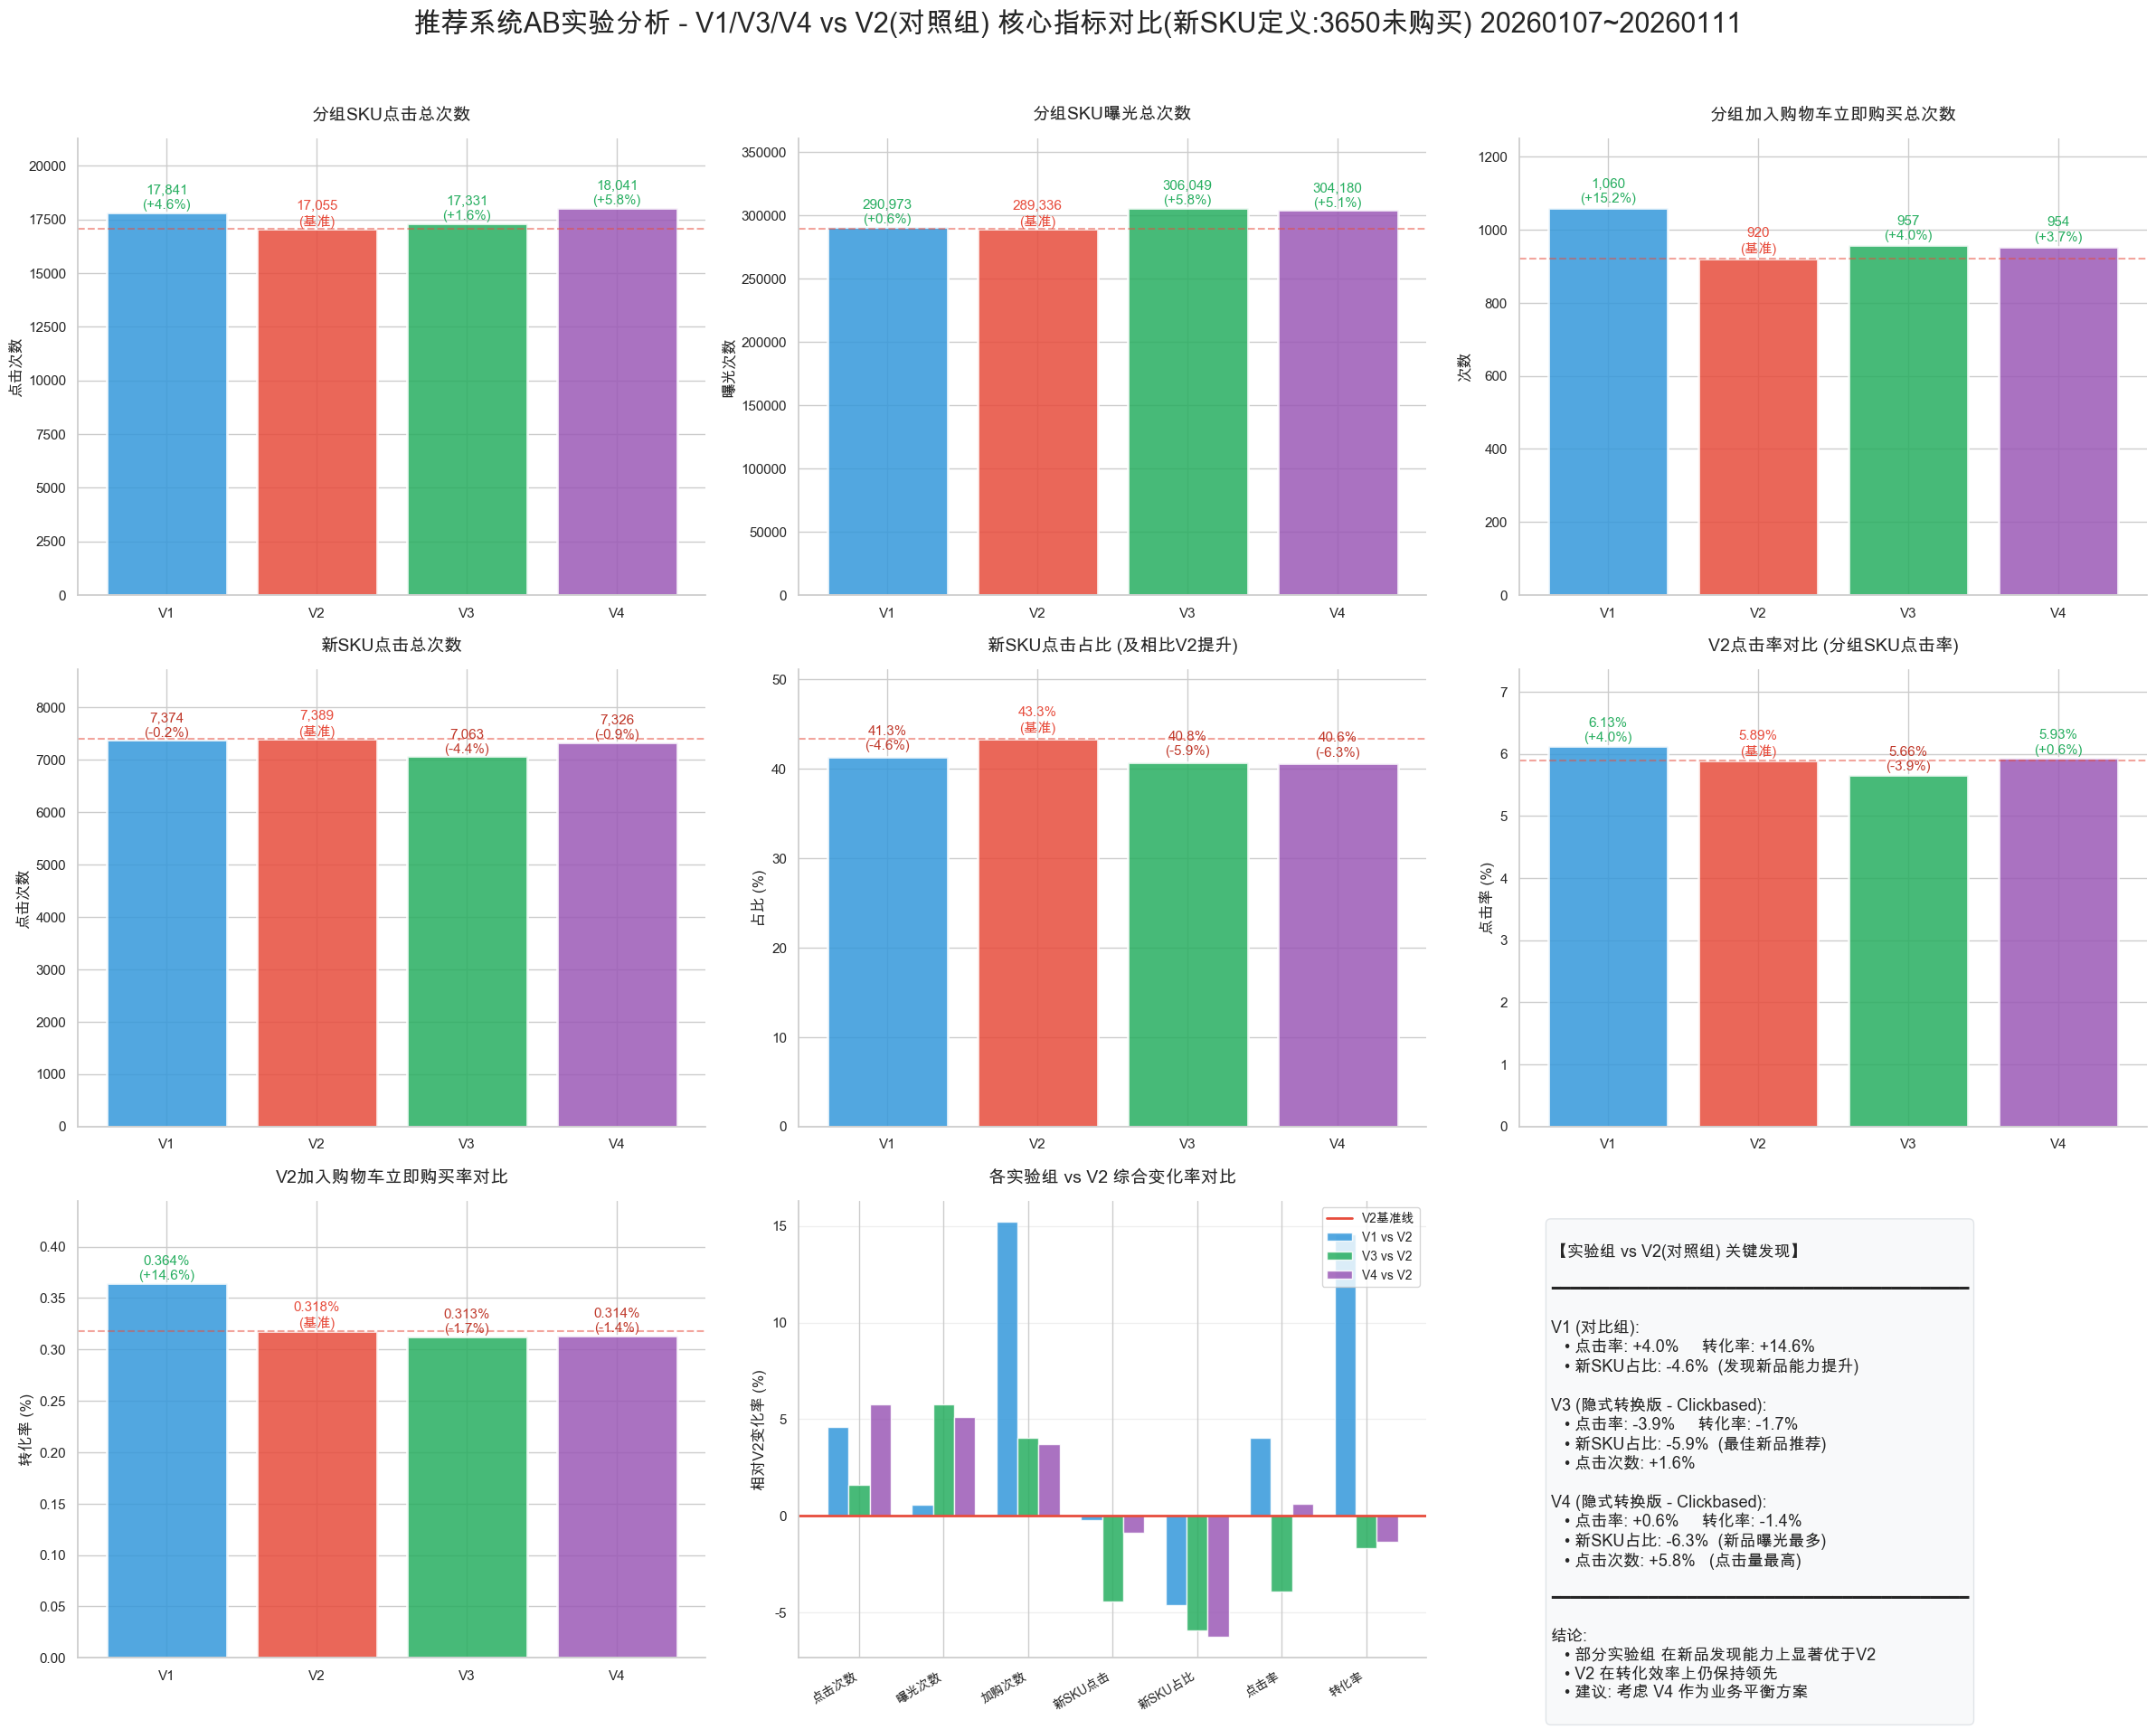


图表已保存: ab_experiment_comparison_final.png


In [44]:
# ================================================================================
# 推荐系统AB实验分析 - V1/V3/V4 vs V2(对照组) 核心指标专业对比图
# ================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False 
sns.set_theme(style="whitegrid", font='Arial Unicode MS')

# ==================== 数据准备 ====================
df = result_final_df.copy()

# 分组级别数据（去重）
df_group = df[['variant_list', '分组sku点击总次数', '分组sku曝光总次数', '分组加入购物车立即购买总次数', 
               '分组SKU点击率', '分组加入购物车立即购买率', 'V2点击率对比', 'V2加入购物车立即购买率对比']].drop_duplicates().reset_index(drop=True)

# 新SKU数据计算
df_new_sku = df[df['是否新sku'] == '新SKU'][['variant_list', 'sku点击总次数']].copy()
df_new_sku.columns = ['variant_list', '新SKU点击次数']
df_total = df.groupby('variant_list')['sku点击总次数'].sum().reset_index()
df_total.columns = ['variant_list', '总点击次数']
df_new_ratio = df_new_sku.merge(df_total, on='variant_list')
df_new_ratio['新SKU点击占比'] = df_new_ratio['新SKU点击次数'] / df_new_ratio['总点击次数']

# V2基准值
v2_new_ratio_val = df_new_ratio[df_new_ratio['variant_list'] == 'V2']['新SKU点击占比'].values[0]
df_new_ratio['新SKU点击占比_vs_V2'] = (df_new_ratio['新SKU点击占比'] - v2_new_ratio_val) / v2_new_ratio_val

# 合并数据
df_plot = df_group.merge(df_new_ratio[['variant_list', '新SKU点击次数', '新SKU点击占比', '新SKU点击占比_vs_V2']], on='variant_list')

# V2基准值
v2_clicks = df_plot[df_plot['variant_list'] == 'V2']['分组sku点击总次数'].values[0]
v2_exposure = df_plot[df_plot['variant_list'] == 'V2']['分组sku曝光总次数'].values[0]
v2_cart = df_plot[df_plot['variant_list'] == 'V2']['分组加入购物车立即购买总次数'].values[0]
v2_ctr = df_plot[df_plot['variant_list'] == 'V2']['分组SKU点击率'].values[0]
v2_cvr = df_plot[df_plot['variant_list'] == 'V2']['分组加入购物车立即购买率'].values[0]
v2_new_click = df_plot[df_plot['variant_list'] == 'V2']['新SKU点击次数'].values[0]

# 颜色方案 - V2红色(对照组)，其他蓝绿紫色系
colors = {'V1': '#3498db', 'V2': '#e74c3c', 'V3': '#27ae60', 'V4': '#9b59b6'}

# ==================== 创建综合图表 ====================
fig = plt.figure(figsize=(24, 20))
fig.suptitle(f'推荐系统AB实验分析 - V1/V3/V4 vs V2(对照组) 核心指标对比(新SKU定义:{DAYS_TO_BE_NEW_SKU}未购买) {date_range}', fontsize=22, fontweight='bold', y=0.98)

# ---------- 图1: 分组SKU点击总次数 ----------
ax1 = fig.add_subplot(3, 3, 1)
bars1 = ax1.bar(df_plot['variant_list'], df_plot['分组sku点击总次数'], 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars1, df_plot.iterrows()):
    height = bar.get_height()
    diff = (row['分组sku点击总次数'] - v2_clicks) / v2_clicks * 100
    label = f'{int(height):,}\n(基准)' if row['variant_list'] == 'V2' else f'{int(height):,}\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax1.text(bar.get_x() + bar.get_width()/2., height + 30, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax1.set_title('分组SKU点击总次数', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('点击次数', fontsize=12)
ax1.set_ylim(0, max(df_plot['分组sku点击总次数']) * 1.18)
ax1.axhline(y=v2_clicks, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ---------- 图2: 分组SKU曝光总次数 ----------
ax2 = fig.add_subplot(3, 3, 2)
bars2 = ax2.bar(df_plot['variant_list'], df_plot['分组sku曝光总次数'], 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars2, df_plot.iterrows()):
    height = bar.get_height()
    diff = (row['分组sku曝光总次数'] - v2_exposure) / v2_exposure * 100
    label = f'{int(height):,}\n(基准)' if row['variant_list'] == 'V2' else f'{int(height):,}\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax2.text(bar.get_x() + bar.get_width()/2., height + 600, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax2.set_title('分组SKU曝光总次数', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('曝光次数', fontsize=12)
ax2.set_ylim(0, max(df_plot['分组sku曝光总次数']) * 1.18)
ax2.axhline(y=v2_exposure, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ---------- 图3: 分组加入购物车立即购买总次数 ----------
ax3 = fig.add_subplot(3, 3, 3)
bars3 = ax3.bar(df_plot['variant_list'], df_plot['分组加入购物车立即购买总次数'], 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars3, df_plot.iterrows()):
    height = bar.get_height()
    diff = (row['分组加入购物车立即购买总次数'] - v2_cart) / v2_cart * 100
    label = f'{int(height):,}\n(基准)' if row['variant_list'] == 'V2' else f'{int(height):,}\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax3.text(bar.get_x() + bar.get_width()/2., height + 8, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax3.set_title('分组加入购物车立即购买总次数', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('次数', fontsize=12)
ax3.set_ylim(0, max(df_plot['分组加入购物车立即购买总次数']) * 1.18)
ax3.axhline(y=v2_cart, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ---------- 图4: 新SKU点击次数 ----------
ax4 = fig.add_subplot(3, 3, 4)
bars4 = ax4.bar(df_plot['variant_list'], df_plot['新SKU点击次数'], 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars4, df_plot.iterrows()):
    height = bar.get_height()
    diff = (row['新SKU点击次数'] - v2_new_click) / v2_new_click * 100
    label = f'{int(height):,}\n(基准)' if row['variant_list'] == 'V2' else f'{int(height):,}\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax4.text(bar.get_x() + bar.get_width()/2., height + 15, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax4.set_title('新SKU点击总次数', fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('点击次数', fontsize=12)
ax4.set_ylim(0, max(df_plot['新SKU点击次数']) * 1.18)
ax4.axhline(y=v2_new_click, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ---------- 图5: 新SKU点击占比 (及相比V2提升) ----------
ax5 = fig.add_subplot(3, 3, 5)
bars5 = ax5.bar(df_plot['variant_list'], df_plot['新SKU点击占比'] * 100, 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars5, df_plot.iterrows()):
    height = bar.get_height()
    diff = row['新SKU点击占比_vs_V2'] * 100
    label = f'{height:.1f}%\n(基准)' if row['variant_list'] == 'V2' else f'{height:.1f}%\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.5, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax5.set_title('新SKU点击占比 (及相比V2提升)', fontsize=14, fontweight='bold', pad=15)
ax5.set_ylabel('占比 (%)', fontsize=12)
ax5.set_ylim(0, max(df_plot['新SKU点击占比'] * 100) * 1.18)
ax5.axhline(y=v2_new_ratio_val * 100, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ---------- 图6: V2点击率对比 (分组SKU点击率) ----------
ax6 = fig.add_subplot(3, 3, 6)
bars6 = ax6.bar(df_plot['variant_list'], df_plot['分组SKU点击率'] * 100, 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars6, df_plot.iterrows()):
    height = bar.get_height()
    diff = row['V2点击率对比'] * 100
    label = f'{height:.2f}%\n(基准)' if row['variant_list'] == 'V2' else f'{height:.2f}%\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.03, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax6.set_title('V2点击率对比 (分组SKU点击率)', fontsize=14, fontweight='bold', pad=15)
ax6.set_ylabel('点击率 (%)', fontsize=12)
ax6.set_ylim(0, max(df_plot['分组SKU点击率'] * 100) * 1.20)
ax6.axhline(y=v2_ctr * 100, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

# ---------- 图7: V2加入购物车立即购买率对比 ----------
ax7 = fig.add_subplot(3, 3, 7)
bars7 = ax7.bar(df_plot['variant_list'], df_plot['分组加入购物车立即购买率'] * 100, 
                color=[colors[v] for v in df_plot['variant_list']], edgecolor='white', linewidth=2, alpha=0.85)
for bar, (_, row) in zip(bars7, df_plot.iterrows()):
    height = bar.get_height()
    diff = row['V2加入购物车立即购买率对比'] * 100
    label = f'{height:.3f}%\n(基准)' if row['variant_list'] == 'V2' else f'{height:.3f}%\n({diff:+.1f}%)'
    color = '#e74c3c' if row['variant_list'] == 'V2' else ('#27ae60' if diff > 0 else '#c0392b')
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.0008, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
ax7.set_title('V2加入购物车立即购买率对比', fontsize=14, fontweight='bold', pad=15)
ax7.set_ylabel('转化率 (%)', fontsize=12)
ax7.set_ylim(0, max(df_plot['分组加入购物车立即购买率'] * 100) * 1.22)
ax7.axhline(y=v2_cvr * 100, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

# ---------- 图8: 各实验组 vs V2 综合变化率对比 ----------
ax8 = fig.add_subplot(3, 3, 8)
metrics = ['点击次数', '曝光次数', '加购次数', '新SKU点击', '新SKU占比', '点击率', '转化率']
v1_changes = [
    (df_plot[df_plot['variant_list']=='V1']['分组sku点击总次数'].values[0] - v2_clicks) / v2_clicks * 100,
    (df_plot[df_plot['variant_list']=='V1']['分组sku曝光总次数'].values[0] - v2_exposure) / v2_exposure * 100,
    (df_plot[df_plot['variant_list']=='V1']['分组加入购物车立即购买总次数'].values[0] - v2_cart) / v2_cart * 100,
    (df_plot[df_plot['variant_list']=='V1']['新SKU点击次数'].values[0] - v2_new_click) / v2_new_click * 100,
    df_plot[df_plot['variant_list']=='V1']['新SKU点击占比_vs_V2'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V1']['V2点击率对比'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V1']['V2加入购物车立即购买率对比'].values[0] * 100
]
v3_changes = [
    (df_plot[df_plot['variant_list']=='V3']['分组sku点击总次数'].values[0] - v2_clicks) / v2_clicks * 100,
    (df_plot[df_plot['variant_list']=='V3']['分组sku曝光总次数'].values[0] - v2_exposure) / v2_exposure * 100,
    (df_plot[df_plot['variant_list']=='V3']['分组加入购物车立即购买总次数'].values[0] - v2_cart) / v2_cart * 100,
    (df_plot[df_plot['variant_list']=='V3']['新SKU点击次数'].values[0] - v2_new_click) / v2_new_click * 100,
    df_plot[df_plot['variant_list']=='V3']['新SKU点击占比_vs_V2'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V3']['V2点击率对比'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V3']['V2加入购物车立即购买率对比'].values[0] * 100
]
v4_changes = [
    (df_plot[df_plot['variant_list']=='V4']['分组sku点击总次数'].values[0] - v2_clicks) / v2_clicks * 100,
    (df_plot[df_plot['variant_list']=='V4']['分组sku曝光总次数'].values[0] - v2_exposure) / v2_exposure * 100,
    (df_plot[df_plot['variant_list']=='V4']['分组加入购物车立即购买总次数'].values[0] - v2_cart) / v2_cart * 100,
    (df_plot[df_plot['variant_list']=='V4']['新SKU点击次数'].values[0] - v2_new_click) / v2_new_click * 100,
    df_plot[df_plot['variant_list']=='V4']['新SKU点击占比_vs_V2'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V4']['V2点击率对比'].values[0] * 100,
    df_plot[df_plot['variant_list']=='V4']['V2加入购物车立即购买率对比'].values[0] * 100
]

x = np.arange(len(metrics))
width = 0.25
bars_v1 = ax8.bar(x - width, v1_changes, width, label='V1 vs V2', color='#3498db', alpha=0.85)
bars_v3 = ax8.bar(x, v3_changes, width, label='V3 vs V2', color='#27ae60', alpha=0.85)
bars_v4 = ax8.bar(x + width, v4_changes, width, label='V4 vs V2', color='#9b59b6', alpha=0.85)
ax8.axhline(y=0, color='#e74c3c', linestyle='-', linewidth=2, label='V2基准线')
ax8.set_ylabel('相对V2变化率 (%)', fontsize=12)
ax8.set_title('各实验组 vs V2 综合变化率对比', fontsize=14, fontweight='bold', pad=15)
ax8.set_xticks(x)
ax8.set_xticklabels(metrics, rotation=30, ha='right', fontsize=10)
ax8.legend(loc='upper right', fontsize=10)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)
ax8.grid(axis='y', alpha=0.3)

# ---------- 图9: 关键结论摘要 (动态数值版) ----------
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')

# 动态提取数值辅助函数 (索引对应 metrics 列表)
# metrics = ['点击次数', '曝光次数', '加购次数', '新SKU点击', '新SKU占比', '点击率', '转化率']
def format_val(val):
    return f"{val:+.1f}%"

summary_text = f"""
【实验组 vs V2(对照组) 关键发现】

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

V1 (对比组):
   • 点击率: {format_val(v1_changes[5])}     转化率: {format_val(v1_changes[6])}
   • 新SKU占比: {format_val(v1_changes[4])}  (发现新品能力提升)

V3 (隐式转换版 - Clickbased):
   • 点击率: {format_val(v3_changes[5])}     转化率: {format_val(v3_changes[6])}
   • 新SKU占比: {format_val(v3_changes[4])}  (最佳新品推荐)
   • 点击次数: {format_val(v3_changes[0])}

V4 (隐式转换版 - Clickbased):
   • 点击率: {format_val(v4_changes[5])}     转化率: {format_val(v4_changes[6])}
   • 新SKU占比: {format_val(v4_changes[4])}  (新品曝光最多)
   • 点击次数: {format_val(v4_changes[0])}   (点击量最高)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

结论:
   • {"V3/V4" if v3_changes[4] > 0 and v4_changes[4] > 0 else "部分实验组"} 在新品发现能力上显著优于V2
   • V2 在转化效率上仍保持领先
   • 建议: 考虑 {"V3" if abs(v3_changes[6]) < abs(v4_changes[6]) else "V4"} 作为业务平衡方案
"""

ax9.text(
    0.05, 0.95, summary_text,
    transform=ax9.transAxes,
    fontsize=13,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='#f8f9fa',
        edgecolor='#dee2e6',
        alpha=0.9
    )
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('ab_experiment_comparison_final.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n图表已保存: ab_experiment_comparison_final.png")
